##**텍스트 분석 실습 - 캐글 Mercari Price Suggestion Challenge**

: 일본의 대형 온라인 쇼핑몰인 Mercari사의 제품에 대해 가격을 예측하는 과제.

[제공되는 데이터 세트의 속성]
- train_id: 데이터 id
- name: 제품명
- item_condition_id: 판매자가 제공하는 제품 상태
- category_name: 카테고리 명
- brand_name: 브랜드 이름
- price: 제품 가격. 예측을 위한 타깃 속성
- shipping: 배송비 무료 여부. 1이면 무료, 0이면 유로
- item_dscription: 제품에 대한 설명

> 이들 중 price가 예측해야 할 타깃 값. 회귀로 피처를 학습한 뒤 price를 예측하는 문제.

<br>

**데이터 전처리**

In [1]:
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
import pandas as pd

mercari_df=pd.read_csv('mercari_train.tsv', sep='\t')
print(mercari_df.shape)
mercari_df.head(3)

(880257, 8)


,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,NaN,10.0,1,No description yet
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & P...,Razer,52.0,0,This keyboard is in great condition and works ...
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,Adorable top with a hint of lace and a key hol...


print(mercari_df.info())

- brand_name 칼럼의 경우 매우 많은 Null 값을 가지고 있음
- Null 데이터들은 이후 적절한 문자열로 치환

<br>

- target 값인 price 칼럼의 데이터 분포도 살펴보기

/tmp/ipykernel_3356/1198184677.py:6: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_train_df, bins=100)


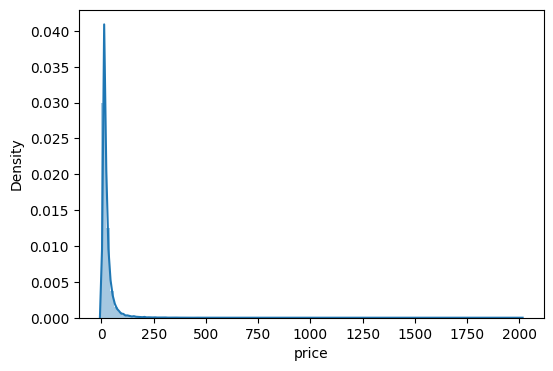

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

y_train_df = mercari_df['price']
plt.figure(figsize=(6, 4))
sns.distplot(y_train_df, bins=100)
plt.show()

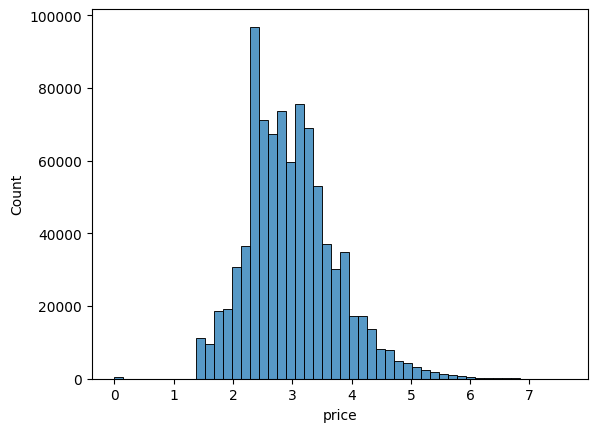

In [3]:
# price 칼럼 로그 값으로 변환 후 분포도 다시 살펴보기
import numpy as np

y_train_df = np.log1p(y_train_df)
sns.histplot(y_train_df, bins=50)
plt.show()

- 로그 값으로 변환하면 price 값이 비교적 정규분포에 가까운 데이터를 이루게 됨

데이터 세트의 price 칼럼을 원래 값에서 로그로 변환된 값으로 변경.



In [4]:
mercari_df['price']=np.log1p(mercari_df['price'])
mercari_df['price'].head(3)

,price
0,2.397895
1,3.970292
2,2.397895


In [5]:
# 다른 피처의 값도 살펴보기
print('Shipping 값 유형:\n', mercari_df['shipping'].value_counts())
print('item_condition_id 값 유형:\n', mercari_df['item_condition_id'].value_counts())

Shipping 값 유형:
 shipping
0    486619
1    393638
Name: count, dtype: int64
item_condition_id 값 유형:
 item_condition_id
1    380355
3    256698
2    222891
4     18896
5      1417
Name: count, dtype: int64


- shipping 칼럼은 배송비 유무이며, 값이 비교적 균일.
- item_condition_id는 판매자가 제공하는 제품 상태로서 각 값이 의미하는 바는 캐글에 기재돼 있지 않아서 알 수 없지만, 1, 2, 3 값이 주를 이루고 있음.
- item_description 칼럼은 Null 값은 별로 없지만, description에 대한 별도 설명이 없는 경우 'No description yet' 값으로 되어 있음.

In [6]:
boolean_cond=mercari_df['item_description'].notnull()
mercari_df[boolean_cond]['item_description'].count()

np.int64(880254)

In [7]:
# apply lambda에서 호출되는 대, 중, 소 분할 함수 생셩, 대, 중, 소 값을 리스트로 반환
def split_cat(category_name):
  try:
    return category_name.split('/')
  except:
    return ['Other_Null', 'Other_Null', 'Other_Null']

# 위의 split_cat()을 apply lambda에서 호출해 대, 중, 소 칼럼을 mercari_df에 생성
mercari_df['cat_dae'], mercari_df['cat_jung'], mercari_df['cat_so'] = \
  zip(*mercari_df['category_name'].apply(lambda x : split_cat(x)))

# 대분류만 값의 유형과 건수를 살펴보고, 중분류, 소분류는 값의 유형이 많으므로 분류 개수만 추출
print('대분류 유형:\n', mercari_df['cat_dae'].value_counts())
print('중분류 유형:', mercari_df['cat_jung'].nunique())
print('소분류 유형:', mercari_df['cat_so'].nunique())

대분류 유형:
 cat_dae
Women                     394200
Beauty                    123719
Kids                      101456
Electronics                72960
Men                        55682
Home                       40436
Vintage & Collectibles     27677
Other                      27075
Handmade                   18317
Sports & Outdoors          14942
Other_Null                  3793
Name: count, dtype: int64
중분류 유형: 114
소분류 유형: 853


- brand_name, category name, item_description 칼럼의 Null 값은 일괄적으로 'Other
Null'로 동일하게 변경
- price 값 결정에 영향을 많이 줄 것으로 판단되지만, Null 값이 매우 많기 때문에, 다른 값으로 변경하는 것은 적절하지 않음. 따라서 일괄적으로 'Other_Null'로 변경

In [8]:
mercari_df['brand_name'] = mercari_df['brand_name'].fillna(value='Other_Null')
mercari_df['category_name'] = mercari_df['category_name'].fillna(value='Other_Null')
mercari_df['item_description'] = mercari_df['item_description'].fillna(value='Other_Null')

# 각 컬럼별로 Null 값 건수 확인. 모두 0이 나와야 합니다.
mercari_df.isnull().sum()

,0
train_id,0
name,0
item_condition_id,0
category_name,0
brand_name,0
price,0
shipping,0
item_description,0
cat_dae,0
cat_jung,0


###**피처 인코딩과 피처 벡터화**

: 문자열 칼럼 중 레이블 또는 원-핫 인코딩을 수행하거나 피처 벡터화로 변한할 칼럼을 선별.

- Mercari Price Suggestion에서 예측 모델은 price 값, 즉 상품 가격을 예측해야 하므로 회귀 모델을 기반으로 함. 선형 회귀 모델과 회긔 트리 모델을 모두 적용할 예정이며, 특히 선형 회귀의 경우 원-핫 인코딩 적용이 훨씬 선호되므로 인코딩할 피처는 모두 원-핫 인코딩 적용.
- 피처 벡터화의 경우는 비교적 짧은 텍스트의 경우는 Count 기반의 벡터화를, 긴 텍스트는 TD-IDF 기반의 벡터화 적용.

In [12]:
print('brand name의 유형 건수 :', mercari_df['brand_name'].nunique())
print('brand name sample 5건 : \n', mercari_df['brand_name'].value_counts()[:5])

brand name의 유형 건수 : 4191
brand name sample 5건 : 
 brand_name
Other_Null           375644
PINK                  31989
Nike                  31918
Victoria's Secret     28614
LuLaRoe               18401
Name: count, dtype: int64


- brand_named의 경우 대부분 명료한 문자열로 되어 있음. 별도의 피처 벡터화 형태로 만들 필요 없이 인코딩 변환을 적용.


In [14]:
print('name의 종류 개수 :', mercari_df['name'].nunique())
print('name sample 7건: \n', mercari_df['name'][:7])

name의 종류 개수 : 751839
name sample 7건: 
 0    MLB Cincinnati Reds T Shirt Size XL
1       Razer BlackWidow Chroma Keyboard
2                         AVA-VIV Blouse
3                  Leather Horse Statues
4                   24K GOLD plated rose
5       Bundled items requested for Ruie
6     Acacia pacific tides santorini top
Name: name, dtype: object


- 상품명은 name 속성의 경우 종류가 매우 많음. Name 속성은 유형이 매우 많고, 적은 단어 위주의 텍스트 형태로 돼 있으므로 Count 기반으로 피처 벡터화 변환을 적용.
- category_name 칼럼에서 cat_dae, cat_jung, cat_so 칼럼도 원-핫 인코딩 적용.
- shipping 칼럼은 배송비 무료 여부로서 0과 1, item_condition_id는 상품 상태로서 1,2,3,4,5의 다섯 가지의 유형의 값을 가지고 있음. 이 두 칼럼 모두 원-핫 인코딩 적용.


In [15]:
pd.set_option('max_colwidth', 200)

# item_description의 평균 문자열 크기
print('item_description 평균 문자열 길이:', mercari_df['item_description'].str.len().mean())

mercari_df['item_description'][:2]

item_description 평균 문자열 길이: 145.74641269538327


,item_description
0,No description yet
1,This keyboard is in great condition and works like it came out of the box. All of the ports are tested and work perfectly. The lights are customizable via the Razer Synapse app on your PC.


- 이제 주요 칼럼을 인코딩 및 피처 벡터화 변환.
- 먼저 name과 item_description 칼럼을 피처 벡터화.
- name 칼럼의 경우 CountVectoriizer, item_description 칼럼은 TfidVectorizer로 변환.


In [16]:
# name 속성에 대한 피처 벡터화 변환
cnt_vec = CountVectorizer()
X_name = cnt_vec.fit_transform(mercari_df.name)

# item_description에 대한 피처 벡터화 변환
tfidf_descp = TfidfVectorizer(max_features=50000, ngram_range=(1,3), stop_words='english')
X_descp = tfidf_descp.fit_transform(mercari_df['item_description'])

print('name vectorization shape:', X_name.shape)
print('item_description vectorization shape:', X_descp.shape)

name vectorization shape: (880257, 79207)
item_description vectorization shape: (880257, 50000)


- CountVectorizer, TfidfVectorizer가 fit_transform()을 통해 반환하는 데이터는 희소 행렬 형태.
- 희소 행렬 객체 변수인 X_name X_descp를 새로 결합해 새로운 데이터 세트로 구성해야 하고,
앞으로 인코딩될 cat dae, catjung, cat_so, brand_name, shipping, item_condition_id도 모두 X_name, X_descp와 결합돼 ML 모델을 실행하는 기반 데이터 세트로 재구성돼야 함.
- 이를 위해서 이 인코딩 대상 칼럼도 밀집 행렬 행태가 아닌 희소 행렬 형태로 인코딩을 적용한 뒤, 함께 결합.

- 사이킷런은 원一핫 인코딩을 위해 OneHotEncoder와 LabelBinarizer
클래스를 제공.
- 이 중 LabelBinarizer 클래스는 희소 행렬 형태의 원-핫 인코딩 변환을 지원.
- 모든 인코딩 대상 칼럼은
LabelBinarizer를 이용해 희소 행렬 형태의 원-핫 인코딩으로 변환.
- 개별 칼럼으로 만들어진
희소 행렬은 사이파이 패키지 sparse 모듈의 hstack( ) 함수를 이용해 결합.
- hstack( ) 함수는 희소 행렬을 손쉽게 칼럼 레벨로 결합할 수 있게 해줌.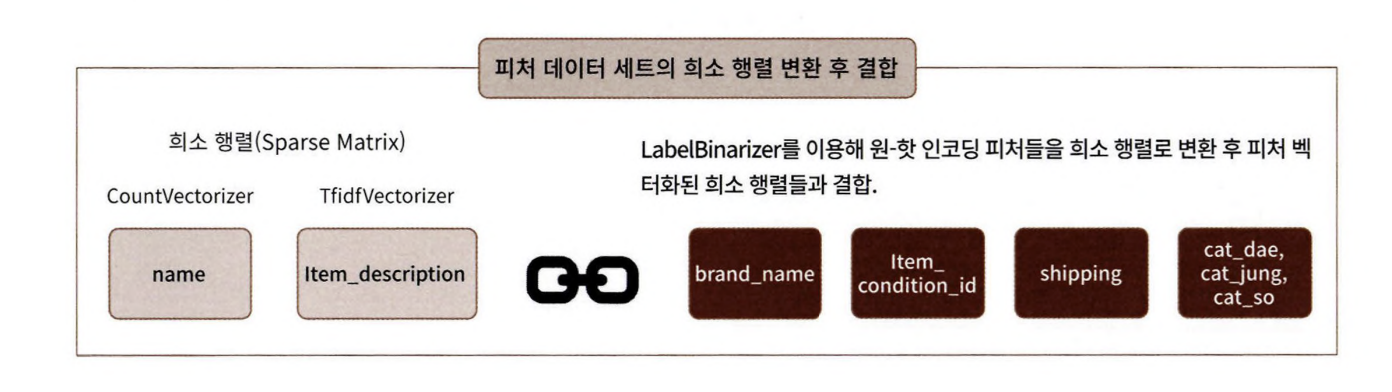

In [17]:
from sklearn.preprocessing import LabelBinarizer

# brand_name, item_condition_id, shipping 각 피처들을 희소 행렬 원-핫 인코딩 변환
lb_brand_name = LabelBinarizer(sparse_output=True)
X_brand = lb_brand_name.fit_transform(mercari_df['brand_name'])
lb_item_cond_id = LabelBinarizer(sparse_output=True)
X_item_cond_id = lb_item_cond_id.fit_transform(mercari_df['item_condition_id'])
lb_shipping = LabelBinarizer(sparse_output=True)
X_shipping = lb_shipping.fit_transform(mercari_df['shipping'])

# cat_dae, cat_jung, cat_so 각 피처들을 희소 행렬 원-핫 인코딩 변환
lb_cat_dae = LabelBinarizer(sparse_output=True)
X_cat_dae = lb_cat_dae.fit_transform(mercari_df['cat_dae'])
lb_cat_jung = LabelBinarizer(sparse_output=True)
X_cat_jung = lb_cat_jung.fit_transform(mercari_df['cat_jung'])
lb_cat_so = LabelBinarizer(sparse_output=True)
X_cat_so = lb_cat_so.fit_transform(mercari_df['cat_so'])

In [19]:
print(type(X_brand), type(X_item_cond_id), type(X_shipping))
print('X_brand shape:{0}, X_item_cond_id shape:{1}'.format(X_brand.shape, X_item_cond_id.shape))
print('X_shipping shape:{0}, X_cat_dae shape:{1}'.format(X_shipping.shape, X_cat_dae.shape))
print('X_cat_jung shape:{0}, X_cat_so shape:{1}'.format(X_cat_jung.shape, X_cat_so.shape))

<class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'> <class 'scipy.sparse._csr.csr_matrix'>
X_brand shape:(880257, 4191), X_item_cond_id shape:(880257, 5)
X_shipping shape:(880257, 1), X_cat_dae shape:(880257, 11)
X_cat_jung shape:(880257, 114), X_cat_so shape:(880257, 853)


- 인코딩 칼럼이 매우 많이 생겼지만, 피처 벡터화로 텍스트 형태의 문자열이 가지는 벡터 혀태의 매우 많은 칼럼과 함께 결합되므로 크게 문제될 것은 없음.
- 이번에는 앞에서 피처 벡터화 변환한 데이터 세트와 희소 인코딩 변환된 데이터 세트를 hstack()을 이용해 모두 결합.
- 결합된 데이터는 Mercari Price Suggestion을 위한 기반 데이터 세트로
사용되는데, 여기서는 결합한 데이터의 타입과 크기만 확인하고 메모리에서 삭제.

- 만들어진 결합 데이터가 비교적 많은 메모리를 잡아먹기 때문에 개인용 PC에서 메모리 오류가 발생할 수 있기에 del ‘객체 변수명’과 gc.collect()로 결합 데이터를 메모리에서 삭제

In [20]:
from scipy.sparse import hstack
import gc

sparse_matrix_list = (X_name, X_descp, X_brand, X_item_cond_id, \
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)

# hstack 함수를 이용해 인코딩과 벡터화를 수행한 데이터 세트를 모두 결합.
X_features_sparse = hstack(sparse_matrix_list).tocsr()
print(type(X_features_sparse), X_features_sparse.shape)

# 데이터 세트가 메모리를 많이 차지하므로 사용 목적이 끝났으면 바로 메모리에서 삭제.
del X_features_sparse
gc.collect()

<class 'scipy.sparse._csr.csr_matrix'> (880257, 134382)


8

###**릿지 회귀 모델 구출 및 평가**

: 여러 알고리즘 모델과 희소 행렬을 변환하고 예측 성능을 비교하면서 테스트를 수행하기

- 먼저 모델을 평가하는 평가 로직 함수화
- 적용할 평가 지표는 RMSLE 방식. 이는 RMSE와 유사하나 오류 값에 로그를 취해 RMSE를 구하는 방식
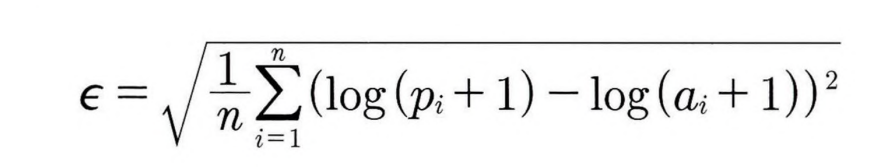
- 한 가지 주의사항은 원본 데이터의 price 칼럼의 값은 왜곡된 데이터 분포를 가지고 있기 때문에 이를 정규 분포 형태로 유도하기 위해 로그 값을 취해 변환함. 따라서 학습 모델을 이용한 예측된 price 값은 다시 로그의 역변환인 지수 변환을 수행해 원복해야 함.

In [27]:
def rmsle(y,y_pred):
  # underflow, overflow를 막기 위해 log가 아닌 log1p로 rmsle 계산
  return np.sqrt(np.mean(np.power(np.log1p(y)-np.log1p(y_pred),2)))

def evaluate_org_price(y_test, preds):

  # 원본 데이터는 log1p로 변환되었으므로 exmpm1로 원복 필요.
  preds_exmpm = np.expm1(preds)
  y_test_exmpm = np.expm1(y_test)

# rmsle로 RMSLE 값 추출
  rmsle_result = rmsle(y_test_exmpm, preds_exmpm)
  return rmsle_result

- 학습용 데이터를 생성하고, 모델을 학습/예측하는 로직을 별도의 함수로 만들기.

In [25]:
import gc
from scipy.sparse import hstack

def model_train_predict(model, matrix_list):
  # scipy.sparse 모듈의 hstack을 이용해 희소 행렬 결합
  X=hstack(matrix_list).tocsr()

  X_train, X_test, y_train, y_test=train_test_split(X, mercari_df['price'],
                                                    test_size=0.2, random_state=156)

  # 모델 학습 및 예측
  model.fit(X_train, y_train)
  preds = model.predict(X_test)

  del X_train, X_test, y_train
  gc.collect()

  return preds, y_test

- 이제 이를 이용해 먼저 Ridge를 이용해 Mercari Price의 회귀 예측을 수행.
- 수행 전 Mercari 상품 가격 예측에 대해  item_description과 같은 텍스트 형태의 속성이 얼마나 영향을 미치는지 알아보기.


In [28]:
linear_model = Ridge(solver = "lsqr", fit_intercept=False)

sparse_matrix_list = (X_name, X_brand, X_item_cond_id, \
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
print('Item Description을 제외했을 때 rmsle 값:', evaluate_org_price(y_test, linear_preds))

sparse_matrix_list = (X_descp, X_name, X_brand, X_item_cond_id, \
                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)
linear_preds, y_test = model_train_predict(model=linear_model, matrix_list=sparse_matrix_list)
print('Item Description을 포함한 rmsle 값:', evaluate_org_price(y_test, linear_preds))

Item Description을 제외했을 때 rmsle 값: 0.5023873582976441
Item Description을 포함한 rmsle 값: 0.47457959973241753


- Item Description을 포함했을 때 rmsle 값이 많이 감소. Item description 영향이 중요함을 알 수 있음.

<br>

###**LightGBM 회귀 모델 구축과 앙상블을 이용한 최종 예측 평가**

: LightGBM을 이용해 회귀를 수행한 뒤, 위에서 구한 릿지 모델 예측값과 LightGBM 모델 예측값을 간단한 앙상블 방식으로 섞어서 최종 회귀 예측값을 평가.

- 먼저 LightGBM으로 회귀 수행.

In [ ]:
# from lightgbm import LGBMRegressor

# sparse_matrix_list = (X_descp, X_name, X_brand, X_item_cond_id,
#                      X_shipping, X_cat_dae, X_cat_jung, X_cat_so)

# lgbm_model = LGBMRegressor(n_estimators=200, learning_rate=0.5, num_leaves=125, random_state=156)
# lgbm_preds, y_test = model_train_predict(model=lgbm_model, matrix_list=sparse_matrix_list)
# print('LightGBM rmsle 값:', evaluate_org_price(y_test, lgbm_preds))

- 앞 예제의 Ridge보다 예측 성능이 더 나아짐.
- 다음으로 이렇게 구한 LightGBM의 예측 결괏값과 위에서 구한 Ridge의 예측 결괏값을 서로 앙상블해 최종 예측 결괏값 도출.
> LightGBM 결괏값에 0.45를 곱하고 Ridge 결괏값에 0.55를 곱한 값을 서로 합해 최종 예측 결괏값으로 함


In [ ]:
# preds = lgbm_preds * 0.45 + linear_preds * 0.55
# print('LightGBM과 Ridge를 ensemble한 최종 rmsle 값:', evaluate_org_price(y_test, preds))